# Vertical gradients — where the centred stencil loses information

The vertical counterpart of
[`field_validation_sparkle.ipynb`](field_validation_sparkle.ipynb).
That notebook took apart the HORIZONTAL artifact — interpolating a
finite difference across the axis it was differenced along.  This one
takes apart the vertical one, which is not the same thing and needs
its own argument.

| | |
|---|---|
| Domain | one 720 × 720 × 51 tile (Section 1) |
| Applies to | the four `_vertical_derivative` call sites — ρ, U, V (and b ≡ ρ×const) — and everything downstream of them |
| Companions | `docs/Gradients.md`, `prompts/field_validation_depth.md` §4b |

## The claim, and the correction to it

`vertical_helpers._vertical_derivative` is **centred** at interior
levels:

    (f[k+1] − f[k−1]) / (z[k+1] − z[k−1])

On even spacing that is identically the mean of the two one-sided
slopes either side of level k.  So it never reads level k, and the
first thing anyone notices is that this looks exactly like the
horizontal sparkle with the interpolation baked into the stencil.

**That framing is half wrong, and the half that is wrong matters.**
Averaging two one-sided slopes does two different things depending on
their signs:

- **Same sign, different magnitude** — a monotone *kink*, e.g. the base
  of the mixed layer where the gradient goes from ~0 above to large
  below.  The centred form returns roughly their mean.  That is a
  correct second-order estimate at a place where the derivative is
  genuinely not well defined.  **Not an error.**
- **Opposite signs** — level k is a vertical *extremum*: an inversion,
  a spike, a one-level step.  The two slopes partly annihilate, the
  centred form collapses toward zero while both one-sided slopes stay
  large.  **This is the artifact**, and it is the real vertical
  analogue of the sparkle.

A metric that does not separate these two overstates the problem
badly, because the mixed-layer base is a kink almost everywhere and
will light up the whole map.  Sections 3 and 4 measure them apart.


## Section 1 — Setup: one tile, full water column

In [1]:
# ---- knobs -------------------------------------------------------------
REGION       = "gulf_stream"          # any region with a 'zoom' anchor
DATE         = "2012-11-09 12:00:00"
LEVELS       = ("sfc", "z25m", "mld", "mld_mean")
ZOOM_HALF_KM = 100.0
# ------------------------------------------------------------------------

import dask
import numpy as np
import xarray as xr

import dbof.preprocessing.calculate_fields as CF
import dbof.preprocessing.calculate_fields_at_depth as CFAD
from dbof.plotting import depth_figures as dfig
from dbof.plotting.field_cmaps import load_field_cmaps
import dbof.utils.native_gradient as NG
from dbof.preprocessing import vertical_helpers as VH
from dbof.tiles import tile_utils
from dbof.tiles.tile_mapping import rect_ij_to_tile

# tile_utils sets the Agg backend on import; restore inline afterwards.
%matplotlib inline
import matplotlib.pyplot as plt

CMAP_CFG, DIVERGING = load_field_cmaps()

S3 = tile_utils._resolve_s3_source(None)
ANCHOR_LON, ANCHOR_LAT = dfig.region_anchor(REGION)
tile = rect_ij_to_tile(
    *tile_utils.latlon_to_rect_ij(ANCHOR_LON, ANCHOR_LAT, S3))
print(f"tile   : idx {tile.tile_idx}, face {tile.face_idx}")

ds_grid = tile_utils._load_grid_for_tile(S3, tile)
ds_raw = tile_utils._load_tracers_for_tile(
    S3, DATE, tile, ["Theta", "Salt", "U", "V", "W"])

# ---------------------------------------------------------------------
# MEMORY -- why this is a SLICE and not a rechunk
# ---------------------------------------------------------------------
# vertical_stencil_ab holds ~8 full 3D intermediates at once, in float64
# (the depth coordinate is float64, so everything downstream upcasts).
# On a full 720x720x51 tile that is ~1.7 GB per field, and ertel_pv adds
# ~10 more of its own.  Across eight fields it kills the kernel.
#
# Rechunking the horizontal LOOKS like the fix and is a trap.  The
# production depth strategies index a 3D field and the 2D MLD together
# inside ONE dask block (_extract_at_mld), so their chunks must match
# exactly -- and xgcm's diff/interp re-block derived fields, so a
# gradient chain ends up chunked differently from the MLD.  The failure
# is an IndexError deep inside the ufunc.  Production never sees it
# because _ensure_depth_chunking uses a single 720x720 block.
#
# So: keep ONE horizontal block, and make the tile SMALLER instead.
# These diagnostics are statistical -- they report fractions over the
# tile -- and a quarter tile is 130k columns, plenty for that.  Slicing
# happens BEFORE _build_tile_context so the grid, the metrics and the
# xgcm object all agree.
SUBTILE = 360        # None = whole tile; 360 = a quarter, 4x less memory

if SUBTILE:
    # CENTRED, not slice(0, SUBTILE).  A corner slice moves the data
    # away from the region anchor, which then puts the zoom box outside
    # the plotted domain -- matplotlib rescales the axes around it and
    # you get a blank margin with the box jammed into a corner.
    _off = (720 - SUBTILE) // 2
    _sl = {d: slice(_off, _off + SUBTILE)
           for d in ("j", "i", "j_g", "i_g")}
    ds_grid = ds_grid.isel({d: v for d, v in _sl.items()
                            if d in ds_grid.dims})
    ds_raw = ds_raw.isel({d: v for d, v in _sl.items()
                          if d in ds_raw.dims})
    print(f"sub-tile : {SUBTILE}x{SUBTILE} "
          f"({(720 / SUBTILE) ** 2:.0f}x less memory than the full tile)")

ds_merge, xgrid = tile_utils._build_tile_context(ds_raw, ds_grid)

XC, YC = dfig.tile_coords(ds_grid)
LAND = dfig.tile_land_mask(ds_grid)

# Zoom on the centre of the domain we are ACTUALLY plotting, not on the
# region anchor -- with SUBTILE set they are not the same point, and a
# box outside the data silently wrecks the figure.  depth_map_grid
# raises if the box does not fit, so this is checked, not assumed.
ZOOM_CENTER = (float(np.nanmedian(XC)), float(np.nanmedian(YC)))
print(f"domain : lon [{np.nanmin(XC):.2f}, {np.nanmax(XC):.2f}], "
      f"lat [{np.nanmin(YC):.2f}, {np.nanmax(YC):.2f}]")
print(f"zoom   : centred at ({ZOOM_CENTER[0]:.2f}, {ZOOM_CENTER[1]:.2f})")

# Depth coordinate, positive downward, and the layer thicknesses.
Z = np.asarray(VH._get_depth_coord(ds_merge).values, dtype=float)
print(f"levels : {len(Z)}, {Z[0]:.1f} m to {Z[-1]:.1f} m")

# Two lazy fields every section below needs.
rho = CF.potential_density(ds_merge)
mld = CFAD.mixed_layer_depth(ds_merge)

/home/lhoffma2/git/llc4320-native-grid-preprocessing/src/dbof/llc4320_ingestion/get_raw_data.py:590: UserWarning: The specified chunks separate the stored chunks along dimension "k" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  grid = xr.open_zarr(
/home/lhoffma2/git/llc4320-native-grid-preprocessing/src/dbof/llc4320_ingestion/get_raw_data.py:590: UserWarning: The specified chunks separate the stored chunks along dimension "k_l" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  grid = xr.open_zarr(


LLC_DEPTH grid file loaded from s3://dbof/LLC4320_RAW/DEPTH/grid.zarr.


/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:324: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(jfac * coords.dims[vname])
/home/lhoffma2/miniforge3/envs/llcngp/lib/python3.12/site-packages/xmitgcm/llcreader/llcmodel.py:322: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  data = np.arange(ifac * coords.dims[vname])


tile   : idx 334, face 10


/home/lhoffma2/git/llc4320-native-grid-preprocessing/src/dbof/llc4320_ingestion/get_raw_data.py:590: UserWarning: The specified chunks separate the stored chunks along dimension "k" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  grid = xr.open_zarr(
/home/lhoffma2/git/llc4320-native-grid-preprocessing/src/dbof/llc4320_ingestion/get_raw_data.py:590: UserWarning: The specified chunks separate the stored chunks along dimension "k_l" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  grid = xr.open_zarr(


LLC_DEPTH grid file loaded from s3://dbof/LLC4320_RAW/DEPTH/grid.zarr.
LLC timestep data loaded: 20121109T12.zarr, vars=['Theta', 'Salt', 'U', 'V', 'W']
sub-tile : 360x360 (4x less memory than the full tile)
domain : lon [-64.24, -56.76], lat [29.70, 35.50]
zoom   : centred at (-60.50, 32.64)
levels : 51, 0.5 m to 945.6 m


/home/lhoffma2/git/llc4320-native-grid-preprocessing/src/dbof/llc4320_ingestion/get_raw_data.py:412: UserWarning: The specified chunks separate the stored chunks along dimension "face" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(


## Section 2 — The mechanism, on one synthetic column

Before touching model data: three profiles where the right answer is
known by construction.  If the diagnostic cannot separate these, it
cannot be trusted on the tile.


In [2]:
# Three profiles on the real model levels.
rho_lin = 1025.0 + 0.004 * Z                       # smooth, no kink
rho_kink = 1025.0 + 0.02 * np.clip(Z - 120.0, 0, None) / 10.0
rho_spike = rho_lin.copy()
rho_spike[20] += 0.35                              # one-level inversion


def stencil_1d(rho):
    """centred, the two one-sided slopes, asym and sign flip."""
    n = len(rho)
    c = np.full(n, np.nan)
    c[1:-1] = (rho[2:] - rho[:-2]) / (Z[2:] - Z[:-2])
    above = np.full(n, np.nan)
    below = np.full(n, np.nan)
    above[1:] = (rho[1:] - rho[:-1]) / (Z[1:] - Z[:-1])
    below[:-1] = (rho[1:] - rho[:-1]) / (Z[1:] - Z[:-1])
    bigger = np.where(np.abs(above) >= np.abs(below), above, below)
    with np.errstate(invalid="ignore", divide="ignore"):
        asym = 1.0 - np.abs(c) / np.abs(bigger)
    flip = (above * below) < 0
    return c, bigger, asym, flip


print(f"{'profile':<12}{'max asym':>10}{'sign flips':>12}  verdict")
print("-" * 62)
for nm, r in (("linear", rho_lin), ("kink", rho_kink),
              ("spike", rho_spike)):
    c, b, a, fl = stencil_1d(r)
    print(f"{nm:<12}{np.nanmax(a):>10.2f}{int(np.nansum(fl)):>12}  "
          + ("clean" if np.nanmax(a) < 0.05 else
             ("CANCELLATION" if fl.any() else "curvature only")))

profile       max asym  sign flips  verdict
--------------------------------------------------------------
linear            0.00           0  clean
kink              0.48           0  curvature only
spike             0.90           2  CANCELLATION


The kink should show a large asymmetry and **zero** sign flips — the
stencil is averaging across a curvature, which is what a centred
difference is supposed to do.  The spike should show sign flips.  That
is the whole distinction, and everything below rests on it.


## Section 3 — The same diagnostic on the tile, on potential density

`dfig.vertical_stencil_ab` computes all four fields lazily on the full
3D volume, then they are reduced to the four depth levels the pipeline
stores.

**How `dz_signflip` reduces matters.**  At `sfc`, `z25m` and `mld` the
depth strategy picks a single level, so the flag stays 0 or 1 and its
mean is the fraction of cells affected.  At `mld_mean` it is
thickness-weighted over the whole layer, so it arrives as a fraction in
[0, 1] and is essentially never exactly 1.  Thresholding it reports
0.0% for a level that is genuinely affected — so it is **averaged, not
thresholded**, and the number means "fraction of the mixed layer
affected" rather than "fraction of cells flagged".


live fields : ['dz_asym_mld', 'dz_asym_mld_mean', 'dz_asym_sfc', 'dz_asym_z25m', 'dz_centred_mld', 'dz_centred_mld_mean', 'dz_centred_sfc', 'dz_centred_z25m', 'dz_onesided_mld', 'dz_onesided_mld_mean', 'dz_onesided_sfc', 'dz_onesided_z25m', 'dz_signflip_mld', 'dz_signflip_mld_mean', 'dz_signflip_sfc', 'dz_signflip_z25m']


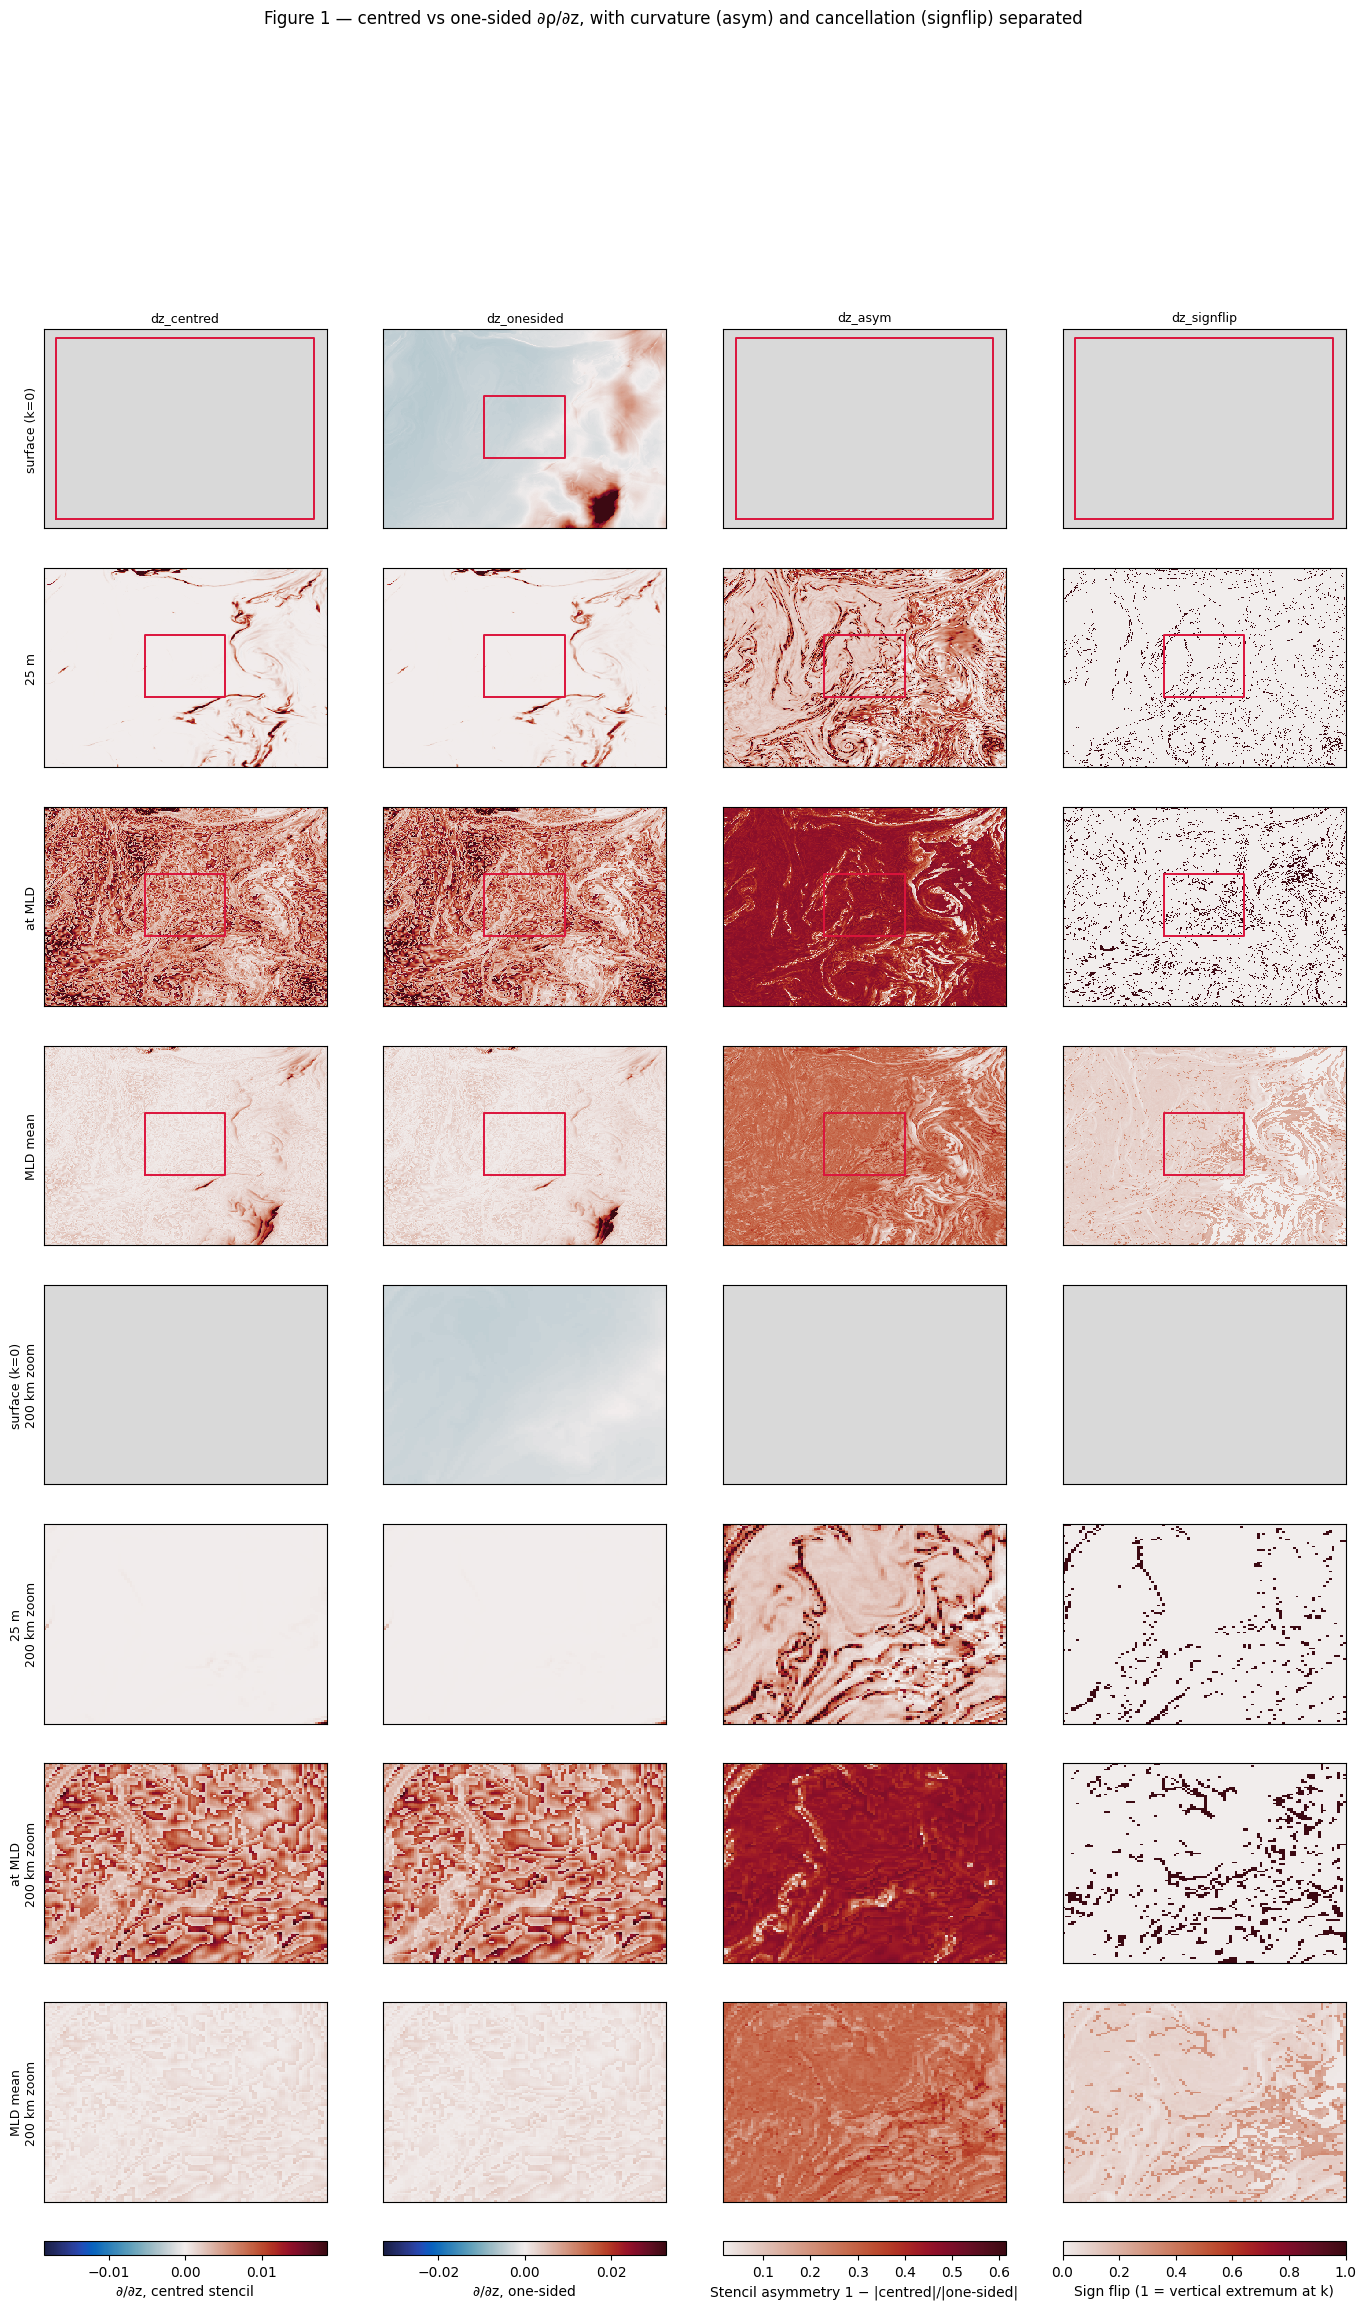

level       median asym  asym>0.25  % flipped
---------------------------------------------
z25m              0.107      19.8%       4.9%
mld               0.444      90.2%       8.9%
mld_mean          0.267      61.8%       9.5%

asym = curvature (benign at a kink).
% flipped = true cancellation; at mld_mean it is the thickness-weighted
            fraction of the layer, not a per-cell flag.


In [3]:
AB = dfig.vertical_stencil_ab(rho, ds_merge)
ab = dfig.pack_tile_levels(
    dfig.compute_levels(AB, ds_merge, mld=mld, levels=LEVELS),
    XC, YC, edge_margin=0, land_mask=LAND, levels=LEVELS,
    verbose=False)

dfig.depth_map_grid(
    ["dz_centred", "dz_onesided", "dz_asym", "dz_signflip"], ab,
    CMAP_CFG, region=REGION, levels=LEVELS,
    diverging_cmaps=DIVERGING,
    zoom_half_km=ZOOM_HALF_KM, zoom_center=ZOOM_CENTER,
    suptitle=("Figure 1 — centred vs one-sided ∂ρ/∂z, with curvature "
              "(asym) and cancellation (signflip) separated"))
plt.show()

print(f"{'level':<10}{'median asym':>13}{'asym>0.25':>11}"
      f"{'% flipped':>11}")
print("-" * 45)
for lev in LEVELS:
    a, sf = ab["dz_asym"][lev][2], ab["dz_signflip"][lev][2]
    if not np.isfinite(a).any():
        continue
    print(f"{lev:<10}{np.nanmedian(a):>13.3f}"
          f"{100 * np.nanmean(a > 0.25):>10.1f}%"
          f"{100 * np.nanmean(sf):>10.1f}%")
print("")
print("asym = curvature (benign at a kink).")
print("% flipped = true cancellation; at mld_mean it is the "
      "thickness-weighted")
print("            fraction of the layer, not a per-cell flag.")

## Section 4 — What does the pipeline actually differentiate?

Before comparing fields, the question has to be asked in the right
order: **which vertical derivatives does the pipeline actually take?**

There are exactly four call sites in `src/dbof`, and the next cell
lists them.  They reduce to three distinct inputs — **potential
density, U and V** — all of them raw or one constant away from raw.

The pipeline **never** takes `∂/∂z` of a horizontal gradient, of a
Jacobian, of `N2`, or of `ertel_pv`.  So for those fields this
diagnostic is **counterfactual**, and plotting them on the same axes as
the real ones without saying so is misleading.  They are still worth
computing, but as a measure of something else — see Figure 2.


In [4]:
# ---------------------------------------------------------------------
# WHAT THE PIPELINE ACTUALLY DIFFERENTIATES IN z
# ---------------------------------------------------------------------
# Every _vertical_derivative call site in src/dbof, in full:
#
#   calculate_fields_at_depth.py:153   _vertical_derivative(rho)  -> N2
#   calculate_fields_at_depth.py:313   _vertical_derivative(U)    -> u_z
#   calculate_fields_at_depth.py:314   _vertical_derivative(V)    -> v_z
#   calculate_fields_at_depth.py:574   _vertical_derivative(b)    -> b_z
#
# That is the complete list.  Three distinct inputs: potential density,
# U and V.  (b = g*sigma0/rho0 is rho times a constant, so d(b)/dz and
# d(rho)/dz have IDENTICAL sign structure -- a useful self-check.)
#
# We NEVER take the vertical derivative of a horizontal gradient, of a
# Jacobian, of N2, or of ertel_pv.  So for those fields the stencil
# diagnostic is COUNTERFACTUAL -- it answers a question the pipeline
# never asks.  They are still worth plotting, but for a different
# reason: see the note under Figure 2.
# jac is shared by two of the probe fields.
jac = CF.compute_velocity_jacobian(ds_merge, xgrid)

# Group A -- the pipeline really does take d/dz of these.
DIFFERENTIATED = {
    "rho": rho,
    "U": ds_merge["U"],
    "V": ds_merge["V"],
}

# Group B -- never differentiated in z.  Here the same diagnostic reads
# as a VERTICAL ROUGHNESS probe: how much fine structure the field has
# from one level to the next.  That is not a stencil error, but it IS
# what governs how badly a field blotches when sampled at a
# staircase-quantised MLD (see mixed_layer_depth.ipynb).
ROUGHNESS_PROBE = {
    "Theta": ds_merge["Theta"],
    "gradb2": CF.grad_b2(ds_merge, xgrid),
    "relative_vorticity": CF.relative_vorticity(
        ds_merge, xgrid, jacobian=jac),
    "N2": CFAD.buoyancy_frequency_squared(ds_merge),
    "ertel_pv": CFAD.ertel_pv_terms(ds_merge, xgrid)["ertel_pv"],
}

ZOO = {**DIFFERENTIATED, **ROUGHNESS_PROBE}
ZOO_KIND = {
    "rho": "DIFFERENTIATED -> N2",
    "U": "DIFFERENTIATED -> u_z",
    "V": "DIFFERENTIATED -> v_z",
    "Theta": "probe: raw tracer",
    "gradb2": "probe: horizontal gradient",
    "relative_vorticity": "probe: horizontal Jacobian",
    "N2": "probe: already a vertical gradient",
    "ertel_pv": "probe: vertical x horizontal product",
}
# Trim this if the kernel still dies, or lower SUBTILE in Section 1.
# ertel_pv is by far the heaviest entry.
ZOO_FIELDS = list(ZOO)

print(f"differentiated by the pipeline : {list(DIFFERENTIATED)}")
print(f"roughness probes only          : {list(ROUGHNESS_PROBE)}")
print(f"running                        : {ZOO_FIELDS}")

differentiated by the pipeline : ['rho', 'U', 'V']
roughness probes only          : ['Theta', 'gradb2', 'relative_vorticity', 'N2', 'ertel_pv']
running                        : ['rho', 'U', 'V', 'Theta', 'gradb2', 'relative_vorticity', 'N2', 'ertel_pv']


In [5]:
# ONE pass per field.  Three things make this fit in memory where the
# obvious version does not:
#
#   1. only dz_signflip and dz_asym are computed -- dz_centred and
#      dz_onesided are not needed here and would double the graph;
#   2. everything is cast to float32;
#   3. the per-level table AND the depth profile come from a SINGLE
#      dask.compute per field, so the shared 3D graph is built once
#      rather than twice.
#
# If the kernel still dies: lower SUBTILE in Section 1, or trim
# ZOO_FIELDS (drop ertel_pv first -- it is several times heavier than
# anything else).
def _mask(a):
    """Squeeze to 2D and blank the land."""
    return np.where(LAND, np.nan, np.squeeze(np.asarray(a)))


table, profiles = {}, {}
for nm in ZOO_FIELDS:
    ab = dfig.vertical_stencil_ab(ZOO[nm], ds_merge)
    sf = ab["dz_signflip"].astype("float32")
    asym = ab["dz_asym"].astype("float32")

    lazy = dfig.reduce_to_levels(sf, "sf", ds_merge, mld, LEVELS)
    lazy.update(dfig.reduce_to_levels(asym, "asym", ds_merge, mld, LEVELS))
    # The depth profile is a 1D reduction -- cheap, and it streams.
    lazy["profile"] = sf.mean(dim=[d for d in sf.dims if d != "k"])

    got = dict(zip(lazy, dask.compute(*lazy.values(), retries=10)))
    table[nm] = {lev: (_mask(got[f"sf_{lev}"]), _mask(got[f"asym_{lev}"]))
                 for lev in LEVELS}
    profiles[nm] = 100 * np.asarray(got["profile"].values, dtype=float)

    del ab, sf, asym, lazy, got
    print(f"  done: {nm}")

  done: rho
  done: U
  done: V
  done: Theta
  done: gradb2
  done: relative_vorticity
  done: N2
  done: ertel_pv


In [6]:
print(f"{'field':<20}{'kind':<32}"
      + "".join(f"{l:>11}" for l in LEVELS))
print("-" * (52 + 11 * len(LEVELS)))
for nm in ZOO_FIELDS:
    pct = "".join(f"{100 * np.nanmean(table[nm][l][0]):>10.1f}%"
                  for l in LEVELS)
    print(f"{nm:<20}{ZOO_KIND[nm]:<32}{pct}")
print("")
print("% of the tile where ∂/∂z of that field straddles a vertical "
      "extremum.")
print("")
print("Only the DIFFERENTIATED rows describe a real pipeline operation.")
print("The probe rows say how much vertical fine structure a field has,")
print("which matters for MLD sampling, not for any ∂/∂z we compute.")

field               kind                                    sfc       z25m        mld   mld_mean
------------------------------------------------------------------------------------------------
rho                 DIFFERENTIATED -> N2                   nan%       4.9%       8.9%       9.5%
U                   DIFFERENTIATED -> u_z                  nan%       2.1%      22.9%       6.2%


/tmp/ipykernel_1490166/514820771.py:5: RuntimeWarning: Mean of empty slice
  pct = "".join(f"{100 * np.nanmean(table[nm][l][0]):>10.1f}%"


V                   DIFFERENTIATED -> v_z                  nan%       6.6%      20.3%       8.7%
Theta               probe: raw tracer                      nan%       3.4%      37.6%      10.2%
gradb2              probe: horizontal gradient             nan%       7.2%      32.0%      13.6%
relative_vorticity  probe: horizontal Jacobian             nan%       5.0%      32.9%       9.9%
N2                  probe: already a vertical gradient       nan%       5.5%       3.6%       7.1%
ertel_pv            probe: vertical x horizontal product       nan%       7.0%       4.0%       8.9%

% of the tile where ∂/∂z of that field straddles a vertical extremum.

Only the DIFFERENTIATED rows describe a real pipeline operation.
The probe rows say how much vertical fine structure a field has,
which matters for MLD sampling, not for any ∂/∂z we compute.


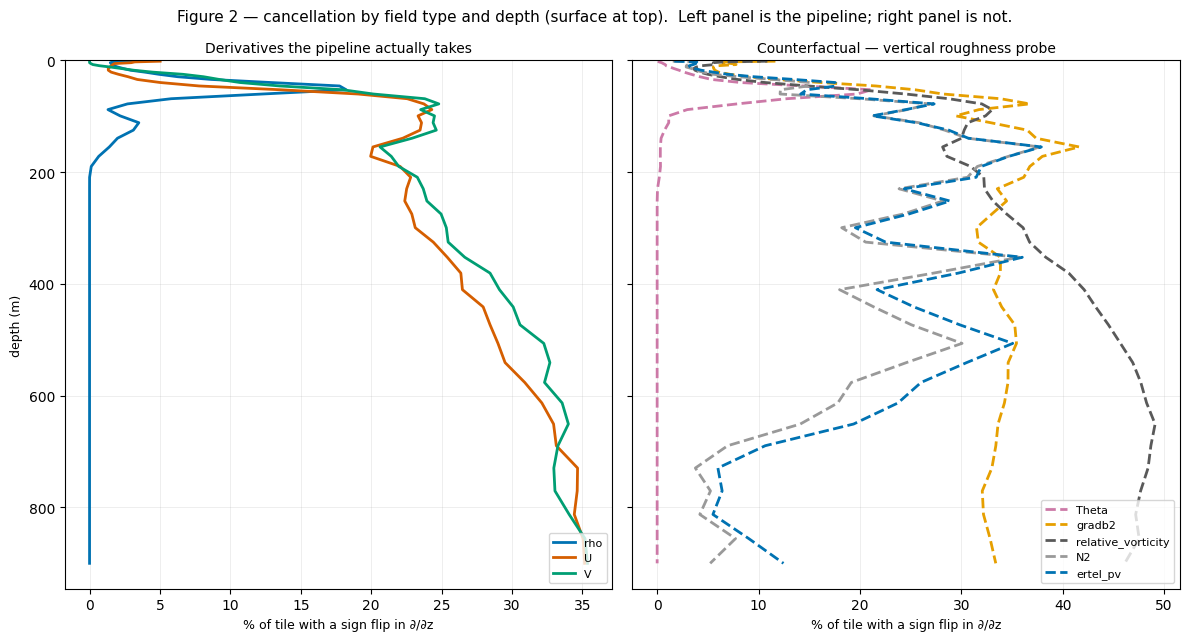

Self-check: d(b)/dz is d(rho)/dz times a constant, so if b were
plotted it would lie exactly on the rho curve.


In [7]:
# SOLID  = a derivative the pipeline really takes.
# DASHED = counterfactual; read as vertical roughness, not as error.
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5), sharey=True)
palette = dfig.LOCATION_COLORS + ("0.35", "0.6")
for i, nm in enumerate(ZOO_FIELDS):
    real = nm in DIFFERENTIATED
    ax = axes[0] if real else axes[1]
    ax.plot(profiles[nm], Z, color=palette[i % len(palette)],
            linewidth=2, linestyle="-" if real else "--", label=nm)

axes[0].set_title("Derivatives the pipeline actually takes", fontsize=10)
axes[1].set_title("Counterfactual — vertical roughness probe",
                  fontsize=10)
for ax in axes:
    ax.set_ylim(Z.max(), 0)
    ax.set_xlabel("% of tile with a sign flip in ∂/∂z", fontsize=9)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=8, loc="lower right")
axes[0].set_ylabel("depth (m)", fontsize=9)
fig.suptitle("Figure 2 — cancellation by field type and depth "
             "(surface at top).  Left panel is the pipeline; right "
             "panel is not.", fontsize=11)
fig.tight_layout()
plt.show()

print("Self-check: d(b)/dz is d(rho)/dz times a constant, so if b were")
print("plotted it would lie exactly on the rho curve.")

**Read the two panels differently.**

The **left** panel is the pipeline's real exposure: `rho`, `U` and `V`
are the only things it differentiates in z.  Whatever number appears
there is the honest size of the vertical stencil problem, and it is the
only one that should influence a decision about `_vertical_derivative`.

The **right** panel is not an error rate.  Those fields are never
differentiated in z, so a high value there does not mean anything is
wrong with them.  It means they have a lot of **vertical fine
structure** — which is a real and useful thing to know, because it
predicts something else entirely:

> A field with lots of vertical structure, sampled at a
> **staircase-quantised** MLD, blotches badly.

That is the mechanism in `mixed_layer_depth.ipynb`, and it explains
why the `_mld` rows of `gradb2`, `relative_vorticity` and `ertel_pv`
look worse than those of `Theta` — not because of any vertical
derivative, but because the MLD sampling lands them on a level that
jumps between neighbouring columns.  The right panel is effectively a
**ranking of which fields need a continuous MLD most.**


## Section 4b — Why U and V flip so much more than density

The left panel of Figure 2 is startling: `rho` sits near zero below
200 m while `U` and `V` climb to 25–37%.  Two candidate explanations,
and they lead to opposite conclusions.

**Candidate 1 — the vertical staggering is wrong.**  U and V are
staggered on the C-grid, so maybe `_vertical_derivative` is using the
tracer depth coordinate for fields that do not live on tracer levels.
The next cell tests this directly.

**Candidate 2 — velocity genuinely has more vertical structure.**
LLC4320 resolves internal tides; the deep flow is weak, wavy and
reverses often.  Every genuine extremum of U(z) is a sign flip.

The distinction matters because of something `dz_signflip` cannot see
on its own: **at a resolved extremum the derivative really is ~0, so
the centred stencil returning ~0 is CORRECT.**  A sign flip is only an
error when the field is oscillating at the grid scale, where no
discretisation resolves anything.  Section 4b tests both.


In [8]:
# Candidate 1: the staggering audit.  What levels does each raw
# variable live on, and which depth coordinate applies?
#
# _get_depth_coord only maps k->Z and k_l->Zl, so ask it only where the
# mapping exists.  W is on the INTERFACES -- k_p1 in this store, 52 of
# them, NOT k_l as the module docstring says -- and is interpolated to
# tracer levels before any depth coordinate is needed, so that gap
# never bites in production.
_ZMAP = {"k": "Z", "k_l": "Zl", "k_u": "Zu", "k_p1": "Zp1"}
print(f"{'variable':<10}{'dims':<34}{'zdim':<7}{'n':<5}{'coord':<7}"
      f"{'first 3 depths (m)'}")
print("-" * 96)
_seen = {}
for _nm in ("Theta", "U", "V", "W"):
    _da = ds_merge[_nm]
    _zd = VH._get_vertical_dim(_da)
    _cn = _ZMAP.get(_zd, "-")
    _z3 = (np.round(ds_merge[_cn].values[:3], 2)
           if _cn in ds_merge else "(no coord in ds_merge)")
    _seen[_nm] = (_zd, _da.sizes[_zd])
    print(f"{_nm:<10}{str(_da.dims):<34}{_zd:<7}{_da.sizes[_zd]:<5}"
          f"{_cn:<7}{_z3}")

print("")
assert _seen["U"][0] == _seen["Theta"][0] == "k", "U not on tracer levels"
assert _seen["V"][0] == _seen["Theta"][0] == "k", "V not on tracer levels"
assert _seen["W"][0] != _seen["Theta"][0], "W should be on interfaces"
print("U and V are on 'k' with coordinate Z -- the SAME vertical levels")
print("as the tracers.  They are staggered HORIZONTALLY (i_g, j_g), not")
print("vertically, so _vertical_derivative uses the right coordinate.")
print("")
print(f"W is on '{_seen['W'][0]}' ({_seen['W'][1]} interfaces) and is")
print("interpolated to tracer levels before any depth coordinate is")
print("needed -- _interp_w_to_tracer_levels reads the dim off the data")
print("rather than assuming it, so k_l and k_p1 both work.")
print("")
print("=> Candidate 1 is RULED OUT.  The staggering is handled correctly.")

variable  dims                              zdim   n    coord  first 3 depths (m)
------------------------------------------------------------------------------------------------
Theta     ('k', 'face', 'j', 'i')           k      51   Z      [-0.5  -1.57 -2.79]
U         ('k', 'face', 'j', 'i_g')         k      51   Z      [-0.5  -1.57 -2.79]
V         ('k', 'face', 'j_g', 'i')         k      51   Z      [-0.5  -1.57 -2.79]
W         ('k_p1', 'face', 'j', 'i')        k_p1   52   Zp1    [ 0.   -1.   -2.14]

U and V are on 'k' with coordinate Z -- the SAME vertical levels
as the tracers.  They are staggered HORIZONTALLY (i_g, j_g), not
vertically, so _vertical_derivative uses the right coordinate.

W is on 'k_p1' (52 interfaces) and is
interpolated to tracer levels before any depth coordinate is
needed -- _interp_w_to_tracer_levels reads the dim off the data
rather than assuming it, so k_l and k_p1 both work.

=> Candidate 1 is RULED OUT.  The staggering is handled correctly.


So the placement is right.  That leaves candidate 2 — and it comes with
a correction to how Figure 2 should be read.

`dz_signflip` marks "level k is a vertical extremum".  It does **not**
distinguish:

- a **resolved** extremum — a jet core, a shear reversal, an
  internal-wave crest.  Here ∂U/∂z genuinely is ~0 and the centred
  stencil is *right*.  Not an error.
- a **2Δz checkerboard** — the slope alternating sign at consecutive
  interfaces.  The field is oscillating at the grid scale, nothing
  resolves it, and the centred stencil is averaging noise.

Only the second is a problem.  `vertical_noise_ab` separates them: it
flags a level only when the slope alternates across *three* consecutive
interfaces, which no physical profile does at the grid scale.


In [9]:
# Candidate 2: how many of the flips are grid-scale checkerboard?
noise = {}
for nm in DIFFERENTIATED:
    nb = dfig.vertical_noise_ab(ZOO[nm], ds_merge)
    ex, oz = dask.compute(
        nb["dz_extremum"].mean(dim=[d for d in nb["dz_extremum"].dims
                                    if d != "k"]),
        nb["dz_2dz"].mean(dim=[d for d in nb["dz_2dz"].dims if d != "k"]),
    )
    noise[nm] = (100 * np.asarray(ex.values, dtype=float),
                 100 * np.asarray(oz.values, dtype=float))
    print(f"  done: {nm}")

print("")
print(f"{'field':<8}{'mean extrema':>14}{'mean 2dz':>11}"
      f"{'2dz share':>12}   verdict")
print("-" * 74)
for nm, (ex, oz) in noise.items():
    share = np.nanmean(oz) / max(np.nanmean(ex), 1e-30)
    print(f"{nm:<8}{np.nanmean(ex):>13.1f}%{np.nanmean(oz):>10.1f}%"
          f"{100 * share:>11.1f}%   "
          + ("GRID NOISE dominates" if share > 0.33 else
             "mostly resolved structure"))
print("")
print("A low 2dz share means the flips are real vertical structure and")
print("the centred stencil is answering correctly (d/dz IS ~0 at an")
print("extremum).  A high share means the profile is oscillating at the")
print("grid scale and the derivative there is meaningless.")

  done: rho
  done: U
  done: V

field     mean extrema   mean 2dz   2dz share   verdict
--------------------------------------------------------------------------
rho               2.6%       0.4%       15.9%   mostly resolved structure
U                19.1%       4.3%       22.5%   mostly resolved structure
V                20.2%       4.5%       22.1%   mostly resolved structure

A low 2dz share means the flips are real vertical structure and
the centred stencil is answering correctly (d/dz IS ~0 at an
extremum).  A high share means the profile is oscillating at the
grid scale and the derivative there is meaningless.


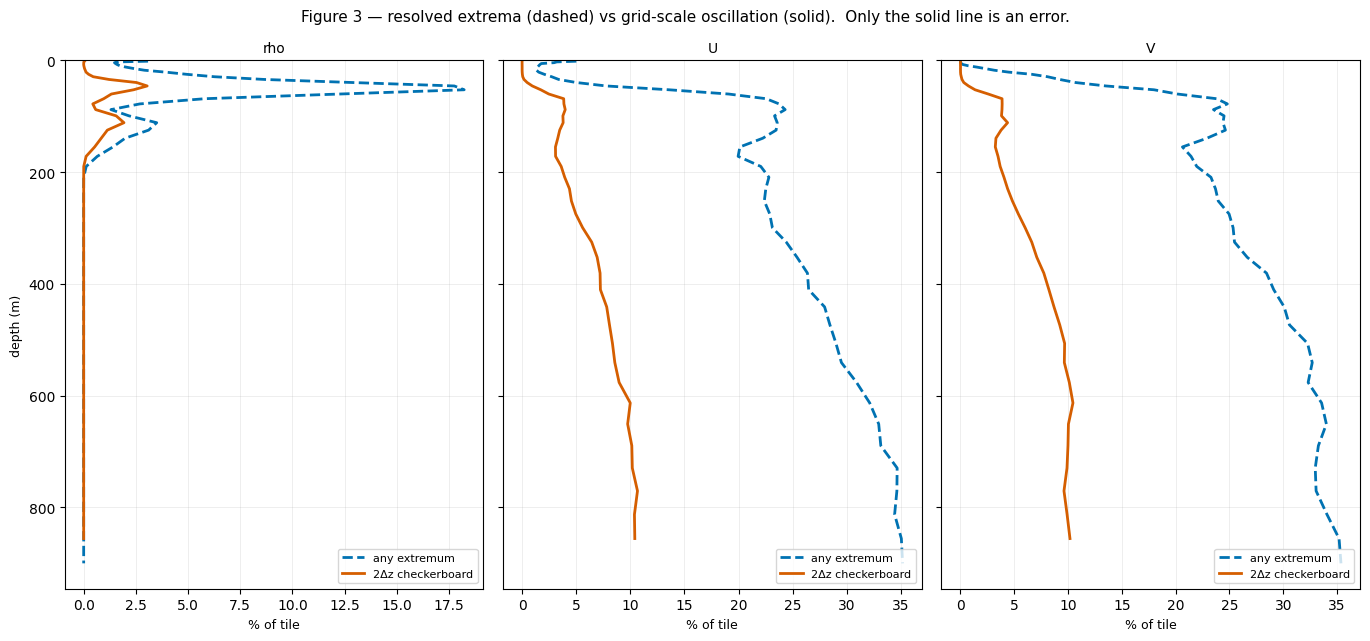

In [10]:
fig, axes = plt.subplots(1, len(noise), figsize=(4.6 * len(noise), 6.5),
                         sharey=True)
for ax, (nm, (ex, oz)) in zip(np.atleast_1d(axes), noise.items()):
    ax.plot(ex, Z, color="#0072B2", linewidth=2, linestyle="--",
            label="any extremum")
    ax.plot(oz, Z, color="#D55E00", linewidth=2, label="2Δz checkerboard")
    ax.set_ylim(Z.max(), 0)
    ax.set_xlabel("% of tile", fontsize=9)
    ax.set_title(nm, fontsize=10)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=8, loc="lower right")
np.atleast_1d(axes)[0].set_ylabel("depth (m)", fontsize=9)
fig.suptitle("Figure 3 — resolved extrema (dashed) vs grid-scale "
             "oscillation (solid).  Only the solid line is an error.",
             fontsize=11)
fig.tight_layout()
plt.show()

## Section 5 — Order of operations: reduce-then-combine vs combine-then-reduce

Everything above is about one derivative.  This section is about what
happens when two of them meet, which is where the depth pipeline has a
real choice to make.

`ertel_pv`'s tilting term contains products like `v_z · b_x` — a
**vertical** gradient times a **horizontal** one.  The pipeline computes
the product in 3D and reduces afterwards.  The alternative is to reduce
each factor to the level first and multiply the 2D results:

- **A (production)**: `reduce(v_z · b_x)`
- **B**: `reduce(v_z) · reduce(b_x)`

For `sfc`, `z25m` and `mld` these are **identical** — the strategy picks
one level, and picking a level commutes with multiplication.

For `mld_mean` they are **not**, because a thickness-weighted mean does
not commute with a product: `mean(a·b) ≠ mean(a)·mean(b)`.  The
difference is the covariance of `a` and `b` over the mixed layer, which
is a real physical quantity, not an error.  A is the mixed-layer
average of the flux; B is the flux of the mixed-layer averages.  They
answer different questions and the pipeline should be explicit about
which one it means.


In [11]:
b = CF.buoyancy_of_field(ds_merge)
b_x, b_y = NG.calculate_native_gradient_tracer(b, ds_merge, grid=xgrid)
u_z, v_z = CFAD.vertical_shear_components(ds_merge, xgrid)

term = v_z * b_x                      # one tilting-term factor pair

# A: combine in 3D, then reduce.  B: reduce each, then combine.
A = dfig.compute_levels({"A": term}, ds_merge, mld=mld, levels=LEVELS,
                        verbose=False)
P = dfig.compute_levels({"vz": v_z, "bx": b_x}, ds_merge, mld=mld,
                        levels=LEVELS, verbose=False)
B = {f"B_{l}": P[f"vz_{l}"] * P[f"bx_{l}"] for l in LEVELS}

order = dfig.pack_tile_levels(
    {**{f"combine_then_reduce_{l}": A[f"A_{l}"] for l in LEVELS},
     **{f"reduce_then_combine_{l}": B[f"B_{l}"] for l in LEVELS}},
    XC, YC, edge_margin=3, land_mask=LAND, levels=LEVELS,
    verbose=False)

print(f"{'level':<12}{'max |A-B| / rms(A)':>22}  verdict")
print("-" * 56)
for lev in LEVELS:
    a = order["combine_then_reduce"][lev][2]
    bb = order["reduce_then_combine"][lev][2]
    rel = np.nanmax(np.abs(a - bb)) / max(
        float(np.sqrt(np.nanmean(a ** 2))), 1e-30)
    same = rel < 1e-4
    print(f"{lev:<12}{rel:>22.3e}  "
          + ("identical (as expected)" if same
             else "DIFFERENT -- covariance term"))

level           max |A-B| / rms(A)  verdict
--------------------------------------------------------
sfc                      0.000e+00  identical (as expected)
z25m                     0.000e+00  identical (as expected)
mld                      1.833e-06  identical (as expected)
mld_mean                 5.744e+00  DIFFERENT -- covariance term


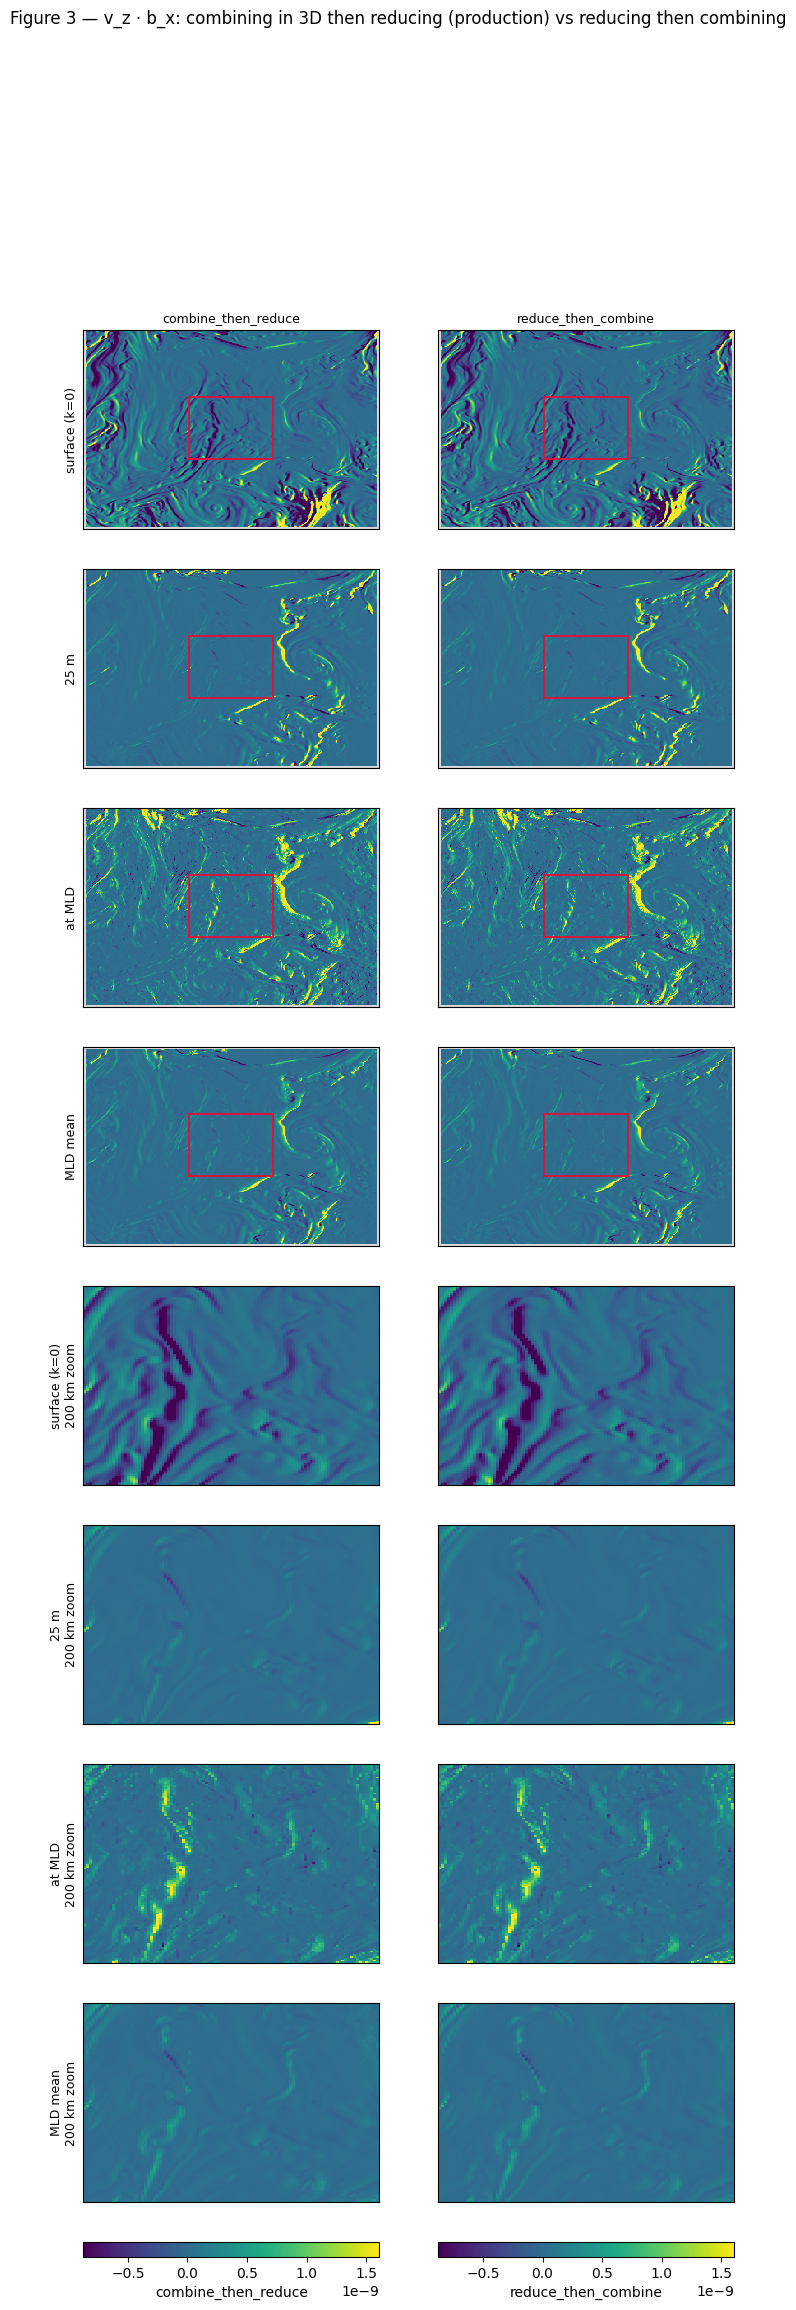

In [12]:
dfig.depth_map_grid(
    ["combine_then_reduce", "reduce_then_combine"], order, CMAP_CFG,
    region=REGION, levels=LEVELS, diverging_cmaps=DIVERGING,
    zoom_half_km=ZOOM_HALF_KM, zoom_center=ZOOM_CENTER,
    suptitle=("Figure 3 — v_z · b_x: combining in 3D then reducing "
              "(production) vs reducing then combining"))
plt.show()

## Section 6 — Decision

Fill in from the numbers above.  Three separable questions:

1. **Is the sign-flip rate material?**  Judge from the LEFT panel of
   Figure 2 (only `rho`, `U`, `V` are actually differentiated) AND from
   Figure 3, which is the one that separates error from physics.  A
   sign flip at a *resolved* extremum is not an error — ∂/∂z genuinely
   is ~0 at a jet core or a wave crest, and the centred stencil is
   right.  Only the **2Δz share** in Figure 3 counts.  U and V flip far
   more often than density because velocity has far more real vertical
   structure (internal tides, shear reversals, weak wavy deep flow),
   not because their staggering is mishandled — Section 4b rules that
   out with an assertion.
2. **Does it concentrate where we sample?**  Figure 2 answers this.  If
   the peak sits near typical MLD depths, the `_mld` row is sampling
   the worst part of the column and that is worth stating in every
   subset notebook.
3. **Which order do we mean for `mld_mean`?**  Section 5 shows the two
   are genuinely different for products.  Production computes
   `mean(a·b)`, the mixed-layer average of the quantity — which is
   almost certainly the intended meaning, but it has never been written
   down, and `docs/Fields.md` should say so.

4. **Which fields most need a continuous MLD?**  The right panel of
   Figure 2 ranks them by vertical roughness, which is what governs
   staircase sensitivity.  Take that ranking to
   `mixed_layer_depth.ipynb` rather than treating it as a stencil
   result.

### If a stencil fix is ever warranted

The vertical grid is staggered: `k_l` levels sit between tracer levels.
A one-sided difference lands naturally on `k_l`, so the vertical
analogue of the horizontal square-before-interp fix does exist —
compute `∂ρ/∂z` on `k_l` and interpolate to `k` only after whatever
squaring the consumer needs.  That changes `N2` and everything below
it, so it is not a change to make on the strength of a map.  Make it on
the strength of Section 4.

---

### Cross-references

- **The horizontal artifact** — `docs/Gradients.md`,
  `field_validation_sparkle.ipynb`.
- **The MLD staircase**, a different mechanism with similar symptoms —
  `mixed_layer_depth.ipynb`.
- **The fields affected** — `depth_fields/vertical_shear.ipynb`,
  `mixing_parameters.ipynb`, `ertel_pv.ipynb`.
